<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [3]:
##Write your code here
print(df['Industry'].value_counts().head(10))

Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Name: count, dtype: int64


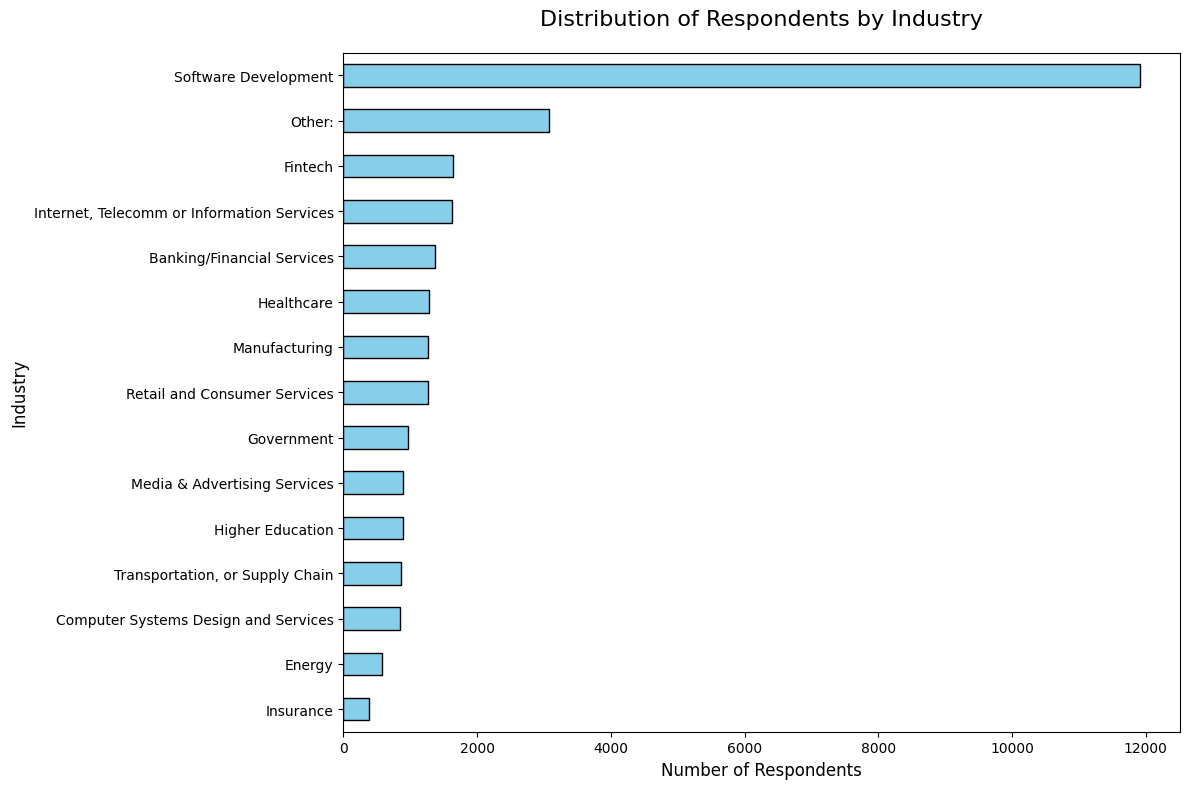

In [4]:
plt.figure(figsize=(12, 8))
industry_counts = df['Industry'].value_counts()
industry_counts.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title('Distribution of Respondents by Industry', fontsize=16, pad=20)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Industry', fontsize=12)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [5]:
##Write your code here
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print("Compensation Statistics:")
print(f"Mean:   ${mean_comp:,.0f}")
print(f"Median: ${median_comp:,.0f}")
print(f"Std Dev: ${std_comp:,.0f}")

Compensation Statistics:
Mean:   $86,155
Median: $65,000
Std Dev: $186,757


In [6]:
threshold = mean_comp + 3 * std_comp
print(f"\nOutlier threshold (mean + 3σ): ${threshold:,.0f}")


Outlier threshold (mean + 3σ): $646,426


In [7]:
outliers = df[df['ConvertedCompYearly'] > threshold]

print(f"\nNumber of high compensation outliers: {len(outliers)}")
print(f"Percentage of total respondents: {len(outliers)/len(df)*100:.2f}%")


Number of high compensation outliers: 89
Percentage of total respondents: 0.14%


In [8]:
print("\nTop 10 highest yearly compensations:")
print(df['ConvertedCompYearly'].sort_values(ascending=False).head(10).map('${:,.0f}'.format))


Top 10 highest yearly compensations:
15837    $16,256,603
12723    $13,818,022
28379     $9,000,000
17593     $6,340,564
17672     $4,936,778
19267     $3,367,716
23694     $2,584,118
33720     $2,237,846
34523     $2,153,432
13763     $2,048,046
Name: ConvertedCompYearly, dtype: object


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [9]:
##Write your code here
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
comp_data = df['ConvertedCompYearly'].dropna()
Q1 = comp_data.quantile(0.25)
Q3 = comp_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR Outlier Detection:")
print(f"Q1 (25th percentile): ${Q1:,.0f}")
print(f"Q3 (75th percentile): ${Q3:,.0f}")
print(f"IQR: ${IQR:,.0f}")
print(f"Lower bound: ${lower_bound:,.0f}")
print(f"Upper bound: ${upper_bound:,.0f}")

IQR Outlier Detection:
Q1 (25th percentile): $32,712
Q3 (75th percentile): $107,972
IQR: $75,260
Lower bound: $-80,177
Upper bound: $220,861


In [10]:
outliers_iqr = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]

print(f"\nNumber of outliers (IQR method): {len(outliers_iqr)}")
print(f"Percentage of total respondents: {len(outliers_iqr)/len(df)*100:.2f}%")


Number of outliers (IQR method): 978
Percentage of total respondents: 1.49%


In [11]:
print("\nTop 10 compensation values classified as outliers:")
print(outliers_iqr['ConvertedCompYearly'].sort_values(ascending=False).head(10).map('${:,.0f}'.format))


Top 10 compensation values classified as outliers:
15837    $16,256,603
12723    $13,818,022
28379     $9,000,000
17593     $6,340,564
17672     $4,936,778
19267     $3,367,716
23694     $2,584,118
33720     $2,237,846
34523     $2,153,432
13763     $2,048,046
Name: ConvertedCompYearly, dtype: object


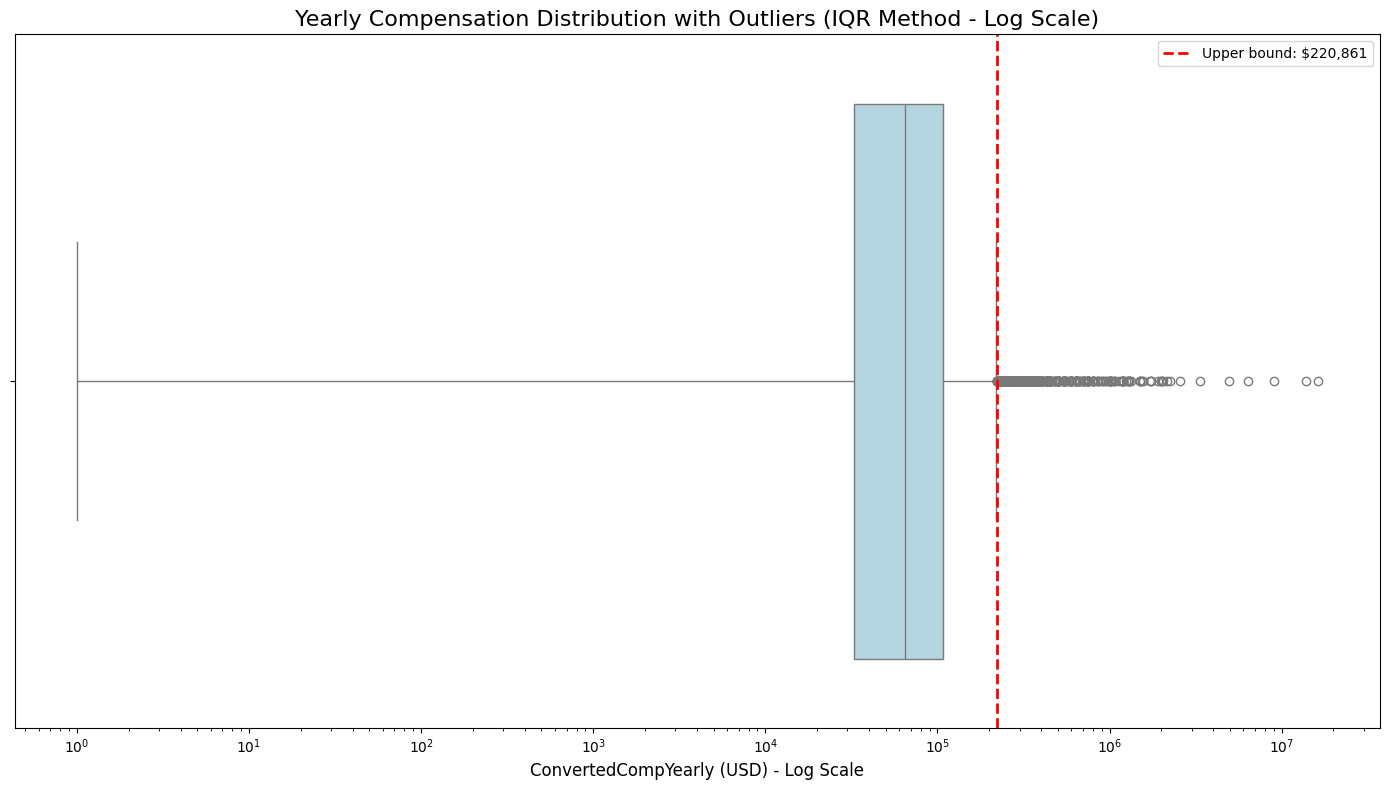

In [19]:
plt.figure(figsize=(14, 8))

sns.boxplot(x=df['ConvertedCompYearly'], color='lightblue')

plt.title('Yearly Compensation Distribution with Outliers (IQR Method - Log Scale)', fontsize=16)
plt.xlabel('ConvertedCompYearly (USD) - Log Scale', fontsize=12)

plt.xscale('log')  # log scale on x-axis

plt.axvline(upper_bound, color='red', linestyle='--', linewidth=2,
            label=f'Upper bound: ${upper_bound:,.0f}')
plt.legend()

plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [20]:
##Write your code here
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & 
                    (df['ConvertedCompYearly'] <= upper_bound)]
original_size = len(df)
new_size = len(df_no_outliers)
removed = original_size - new_size

print(f"Original DataFrame size: {original_size} rows")
print(f"New DataFrame size (without outliers): {new_size} rows")
print(f"Rows removed: {removed} ({removed / original_size * 100:.2f}%)")

Original DataFrame size: 65437 rows
New DataFrame size (without outliers): 22457 rows
Rows removed: 42980 (65.68%)


In [21]:
remaining_outliers = df_no_outliers[df_no_outliers['ConvertedCompYearly'] > upper_bound] # Checking that no outliers remain
print(f"\nOutliers remaining after removal: {len(remaining_outliers)}")


Outliers remaining after removal: 0


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [24]:
##Write your code here
df_no_outliers = df[df['ConvertedCompYearly'] <= upper_bound].copy()
original_size = len(df)
new_size = len(df_no_outliers)
removed = original_size - new_size

print(f"Original DataFrame size: {original_size} rows")
print(f"New DataFrame size (upper outliers removed): {new_size} rows")
print(f"Rows removed: {removed} ({removed / original_size * 100:.2f}%)")

Original DataFrame size: 65437 rows
New DataFrame size (upper outliers removed): 22457 rows
Rows removed: 42980 (65.68%)


In [25]:
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None  # Will become NaN
}

df_no_outliers['AgeNumeric'] = df_no_outliers['Age'].map(age_mapping)
df_no_outliers['YearsCodePro'] = pd.to_numeric(df_no_outliers['YearsCodePro'], errors='coerce')
df_no_outliers['JobSat'] = pd.to_numeric(df_no_outliers['JobSat'], errors='coerce')

numeric_cols = ['AgeNumeric', 'YearsCodePro', 'ConvertedCompYearly', 'JobSat']
corr_df = df_no_outliers[numeric_cols].corr()

print("Correlation Matrix:")
print(corr_df.round(3))

Correlation Matrix:
                     AgeNumeric  YearsCodePro  ConvertedCompYearly  JobSat
AgeNumeric                1.000         0.822                0.370   0.067
YearsCodePro              0.822         1.000                0.387   0.100
ConvertedCompYearly       0.370         0.387                1.000   0.075
JobSat                    0.067         0.100                0.075   1.000


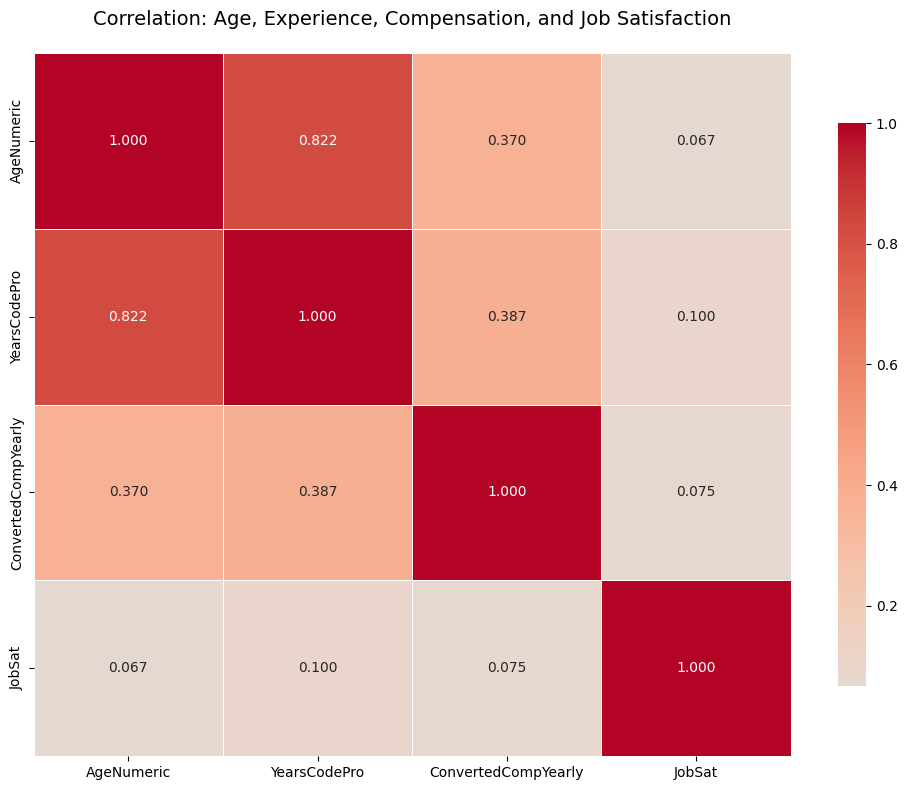

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation: Age, Experience, Compensation, and Job Satisfaction', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
